# Acoustically Constrained Gradient Optimization
Optimize MRI diffusion gradients with hardware limits ($G_{max}$, $S_{max}$) and physiological safety thresholds (PNS, CS). 
Includes an acoustic constraint to suppress energy in the scanner's mechanical resonance frequencies, reducing acoustic vibrations and noise for patient comfort and gradient coil longevity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from timeit import default_timer as timer

import gropt
# from gropt.diff import diff_min_TE
from gropt.diff_v2 import diff_min_TE
# gropt.setup_logging(level=3)

# Load scanner constraints (Gradient system properties)
[asc_file, extra] = gropt.readasc.readasc(r'E:\MGH\Healthy_Grad\asc\CimaX.asc')

# Extract forbidden acoustic resonances and physiological limits (PNS and CS)
forbidden_frequency = gropt.readasc.asc_to_acoustic_resonances(asc_file)
[safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(r'E:\MGH\Healthy_Grad\asc\CimaX.asc')

print("Safe Parameters:", safe_params)
print("Safe Parameters (Cardiac):", safe_params_cardiac)

# Separate forbidden frequencies and their bandwidths into lists
forbidden_frequencies = [f['frequency'] for f in forbidden_frequency]
forbidden_bandwidths = [f['bandwidth'] for f in forbidden_frequency]

print("Forbidden Frequencies (Hz):", forbidden_frequencies)
print("Forbidden Bandwidths (Hz):", forbidden_bandwidths)

Safe Parameters: {'tau1': array([0.0006  , 0.000889, 0.000839]), 'tau2': array([0.012, 0.012, 0.012]), 'tau3': array([0.0002  , 0.000193, 0.0002  ]), 'a1': array([0.412, 0.439, 0.3  ]), 'a2': array([0.2  , 0.3  , 0.273]), 'a3': array([0.388, 0.261, 0.427]), 'stim_limit': array([37.077, 22.988, 32.209]), 'g_scale': array([0.3324, 0.3369, 0.3059])}
Safe Parameters (Cardiac): {'tau1': array([0.0026, 0.0026, 0.0026]), 'tau2': array([0.0018, 0.0018, 0.0018]), 'tau3': array([0.001, 0.001, 0.001]), 'a1': array([0.743, 0.743, 0.743]), 'a2': array([0.257, 0.257, 0.257]), 'a3': array([0, 0, 0]), 'stim_limit': array([17.15, 17.38, 15.78]), 'g_scale': array([0.3324, 0.3369, 0.3059])}
Forbidden Frequencies (Hz): [576, 1113]
Forbidden Bandwidths (Hz): [100, 344]


## 1. Scanner Context & Hardware Limits
Load scanner properties from a system `.asc` file to identify forbidden acoustic frequencies and SAFE parameters for PNS/CS modeling. Define hardware limits (max gradient amplitude, slew rate) and sequence timing.

In [2]:
# Hardware Limits
dt = 50e-6       # Dwell time (s)
# dt = 40e-6
gmax = 200*1e-3  # Maximum gradient (T/m)   
smax = 200       # Maximum slew rate (T/m/s)

# Sequence timing variables for standard PGSE block
T_90 = 3e-3      # 90-degree RF duration (s)
T_180 = 6e-3     # 180-degree RF duration (s)
T_readout = 16e-3# Readout block duration (s)
b = 2000         # Target b-value (s/mm^2)

print("Configuring parameters for Baseline Comparison...")
# Define baseline search constraints without acoustic penalties
search_params_base = {
    'bvalue': b,                 
    'dt': dt,                    
    'T_90': T_90,                
    'T_180': T_180,              
    'T_readout': T_readout,      
    'gmax': gmax,                
    'smax': smax,                
    'MMT': 1,                    # First moment nulling (motion compensation)
    'pns_lim': 0.8,              # Cap PNS at 80% threshold
    'pns_params': safe_params,
    'pns_axis': 1,               # Optimize PNS directly along the Y-Axis
    'cns_lim': 0.8,              # Cap CS at 80% threshold
    'cns_params': safe_params_cardiac,
    'cns_axis': 1,               # Optimize CS directly along the Y-Axis
    'tv1_lam': 1e-18,            # Gradient TV regularization
    'tv1_weight': 5e5,
    'tv2_lam': 4e-4,             # Slew rate TV regularization
    'tv2_weight': 5e5,
    'identity_lam': 1e-5,        # Low L2 penalty for conditioning
}

# Duplicate baseline settings but apply acoustic bans
search_params_ac = search_params_base.copy()
search_params_ac['acoustic'] = {
    'freqs': forbidden_frequencies,
    'bws': forbidden_bandwidths
}

Configuring parameters for Baseline Comparison...


## 2. Execute Gradient Optimization
Solve the inverse problem using `diff_min_TE` for two scenarios:
1. **Baseline Optimization:** Constrained by hardware and safety thresholds.
2. **Acoustic Constrained:** Adds acoustic penalties to smooth waveforms in forbidden frequency bands.

In [3]:
print("Running Baseline GrOpt...")
# Compute shortest Time Equivalent (TE) while hitting the target b-value for baseline
best_TE_base, result_base = diff_min_TE(search_params_base, target_bval=b)
print(f"Base TE: {best_TE_base*1e3:.2f} ms")
print(f"Base b-value: {result_base.bvalue:.2f} s/mm^2")
grad_base = result_base.X

print("\nRunning Acoustically Constrained GrOpt...")
# Re-compute minimum TE for the acoustically constrained version
best_TE_ac, result_ac = diff_min_TE(search_params_ac, target_bval=b)
print(f"Acoustic TE: {best_TE_ac*1e3:.2f} ms")
print(f"Acoustic b-value: {result_ac.bvalue:.2f} s/mm^2")
grad_ac = result_ac.X

Running Baseline GrOpt...
Searching TE: 
[TE: 87.00, b: 8597.27] 
[TE: 70.50, b: 3783.83] 
[TE: 62.25, b: 2048.45] 
[TE: 58.12, b: 1420.30] 
[TE: 60.19, b: 1722.89] 
[TE: 61.22, b: 1808.21] 
[TE: 61.73, b: 1821.95] 
[TE: 61.99, b: 2012.08] 
[TE: 61.86, b: 1992.58] 
[TE: 61.93, b: 1957.61] Done!
Refining at Best TE: 61.99 ms with exact target B-value...
Base TE: 61.99 ms
Base b-value: 1999.02 s/mm^2

Running Acoustically Constrained GrOpt...
Searching TE: 
[TE: 87.00, b: 8659.62] 
[TE: 70.50, b: 2984.14] 
[TE: 62.25, b: 1671.34] 
[TE: 66.37, b: 2288.63] 
[TE: 64.31, b: 1965.02] 
[TE: 65.34, b: 2106.35] 
[TE: 64.83, b: 2005.63] 
[TE: 64.57, b: 1894.60] 
[TE: 64.70, b: 1829.31] 
[TE: 64.76, b: 1978.66] Done!
Refining at Best TE: 64.83 ms with exact target B-value...
Acoustic TE: 64.83 ms
Acoustic b-value: 1999.01 s/mm^2


## 3. Visualize & Analyze Output Quality
Evaluate gradient profiles in the frequency and time domains.
Plot metrics (power spectral density, dynamic time-courses for PNS/CS simulations for the Y-Axis) to compare energy distribution and verify safety thresholds.

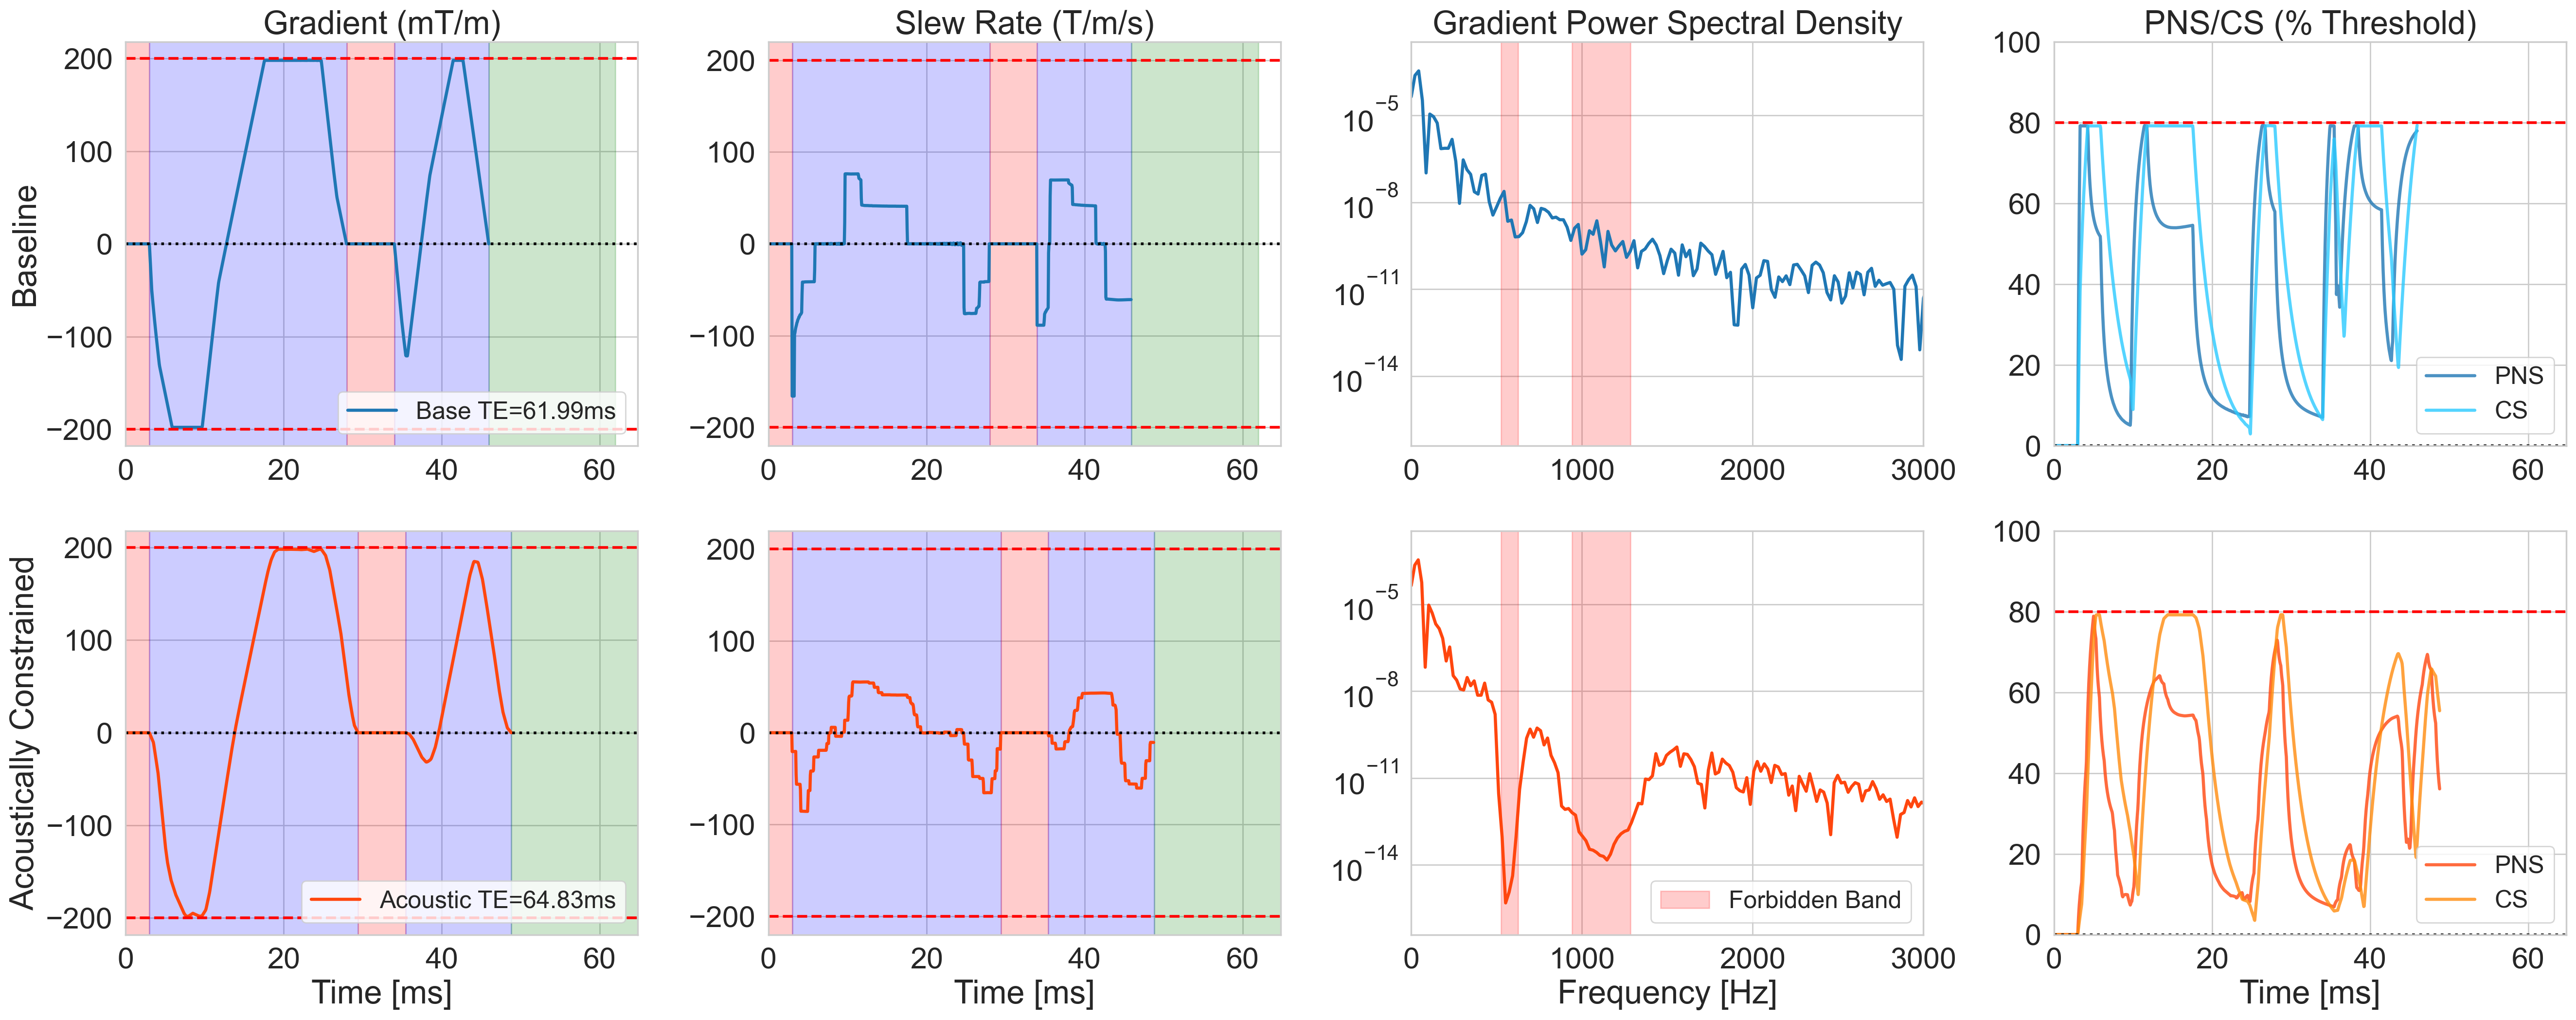

In [4]:
# PSD setup
fs = 1.0 / dt
nperseg_base = min(2048, len(grad_base))
xf_base, psd_base = welch(grad_base, fs=fs, window="hann", nperseg=nperseg_base, noverlap=nperseg_base//2, scaling="density")

nperseg_ac = min(2048, len(grad_ac))
xf_ac, psd_ac = welch(grad_ac, fs=fs, window="hann", nperseg=nperseg_ac, noverlap=nperseg_ac//2, scaling="density")

# SAFE prediction via Y-Axis (new_first_axis=1) as it tends to be the highest PNS constraint under acoustic geometries
safe_base = gropt.gropt_wrapper.get_SAFE(grad_base, dt, new_first_axis=1, demo_params=False, safe_params=safe_params)
safe_cardiac_base = gropt.gropt_wrapper.get_SAFE(grad_base, dt, new_first_axis=1, demo_params=False, safe_params=safe_params_cardiac)

safe_ac = gropt.gropt_wrapper.get_SAFE(grad_ac, dt, new_first_axis=1, demo_params=False, safe_params=safe_params)
safe_cardiac_ac = gropt.gropt_wrapper.get_SAFE(grad_ac, dt, new_first_axis=1, demo_params=False, safe_params=safe_params_cardiac)

# Plot formatting mirroring ISMRM
sns.set_theme(font_scale=2.0, style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(27, 11), dpi=200)
colors = ['#1f77b4', "#FF460E"]  # Blue for baseline, Orange for acoustic

# Row 1: Baseline GrOpt
time_base = np.arange(len(grad_base)) * dt * 1e3
axes[0, 0].plot(time_base, grad_base*1000, linewidth=2.33, color=colors[0], label=f'Base TE={best_TE_base*1e3:.2f}ms')
axes[0, 1].plot(time_base[:-1], np.diff(grad_base)/dt, linewidth=2.33, color=colors[0])
axes[0, 2].semilogy(xf_base, psd_base, linewidth=2.33, color=colors[0])
axes[0, 3].plot(time_base, safe_base*100, linewidth=2.33, color=colors[0], label='PNS', alpha=0.8)
axes[0, 3].plot(time_base, safe_cardiac_base*100, linewidth=2.33, color="#2bcaff", label='CS', alpha=0.8)

# Row 2: Acoustic GrOpt
time_ac = np.arange(len(grad_ac)) * dt * 1e3
axes[1, 0].plot(time_ac, grad_ac*1000, linewidth=2.33, color=colors[1], label=f'Acoustic TE={best_TE_ac*1e3:.2f}ms')
axes[1, 1].plot(time_ac[:-1], np.diff(grad_ac)/dt, linewidth=2.33, color=colors[1])
axes[1, 2].semilogy(xf_ac, psd_ac, linewidth=2.33, color=colors[1])
axes[1, 3].plot(time_ac, safe_ac*100, linewidth=2.33, color=colors[1], label='PNS', alpha=0.8)
axes[1, 3].plot(time_ac, safe_cardiac_ac*100, linewidth=2.33, color="#FF8B0E", label='CS', alpha=0.8)

# Highlight Acoustic Frequency Bands
for idx, (f, bw) in enumerate(zip(forbidden_frequencies, forbidden_bandwidths)):
    axes[0, 2].axvspan(f - bw / 2, f + bw / 2, alpha=0.2, color="red")
    axes[1, 2].axvspan(f - bw / 2, f + bw / 2, alpha=0.2, color="red", label="Forbidden Band" if idx == 0 else None)

# Formatting hardware thresholds
for i in range(2):
    axes[i, 0].axhline(gmax*1000, color='red', linestyle='--', linewidth=2)
    axes[i, 0].axhline(-gmax*1000, color='red', linestyle='--', linewidth=2)
    axes[i, 0].axhline(0, color='black', linestyle=':', linewidth=2)
    axes[i, 0].set_xlim([0, max(best_TE_ac, best_TE_base)*1e3])
    axes[i, 1].axhline(smax, color='red', linestyle='--', linewidth=2)
    axes[i, 1].axhline(-smax, color='red', linestyle='--', linewidth=2)
    axes[i, 1].axhline(0, color='black', linestyle=':', linewidth=2)
    axes[i, 1].set_xlim([0, max(best_TE_ac, best_TE_base)*1e3])
    axes[i, 2].set_xlim([0, 3000])
    axes[i, 2].set_ylim([min(psd_base.min(), psd_ac.min())*0.1, max(psd_base.max(), psd_ac.max())*10])
    axes[i, 3].axhline(search_params_base['pns_lim']*100, color='red', linestyle='--', linewidth=2)
    axes[i, 3].axhline(0, color='black', linestyle=':', linewidth=2)
    axes[i, 3].set_xlim([0, max(best_TE_ac, best_TE_base)*1e3])
    axes[i, 3].set_ylim([0, 100])


for i in range(2):
    axes[0, i].axvspan(0, search_params_base['T_90']*1e3, alpha=0.2, color='red')
    axes[0, i].axvspan(search_params_base['T_90']*1e3, (best_TE_base-search_params_base['T_180'])/2*1e3, alpha=0.2, color='blue')
    axes[0, i].axvspan((best_TE_base-search_params_base['T_180'])/2*1e3, (best_TE_base+search_params_base['T_180'])/2*1e3, alpha=0.2, color='red')
    axes[0, i].axvspan((best_TE_base+search_params_base['T_180'])/2*1e3, time_base[-1], alpha=0.2, color='blue')
    axes[0, i].axvspan(time_base[-1], best_TE_base*1e3, alpha=0.2, color='green')
    
    axes[1, i].axvspan(0, search_params_ac['T_90']*1e3, alpha=0.2, color='red')
    axes[1, i].axvspan(search_params_ac['T_90']*1e3, (best_TE_ac-search_params_ac['T_180'])/2*1e3, alpha=0.2, color='blue')
    axes[1, i].axvspan((best_TE_ac-search_params_ac['T_180'])/2*1e3, (best_TE_ac+search_params_ac['T_180'])/2*1e3, alpha=0.2, color='red')
    axes[1, i].axvspan((best_TE_ac+search_params_ac['T_180'])/2*1e3, time_ac[-1], alpha=0.2, color='blue')
    axes[1, i].axvspan(time_ac[-1], best_TE_ac*1e3, alpha=0.2, color='green')



axes[0,0].set_title('Gradient (mT/m)')
axes[0,1].set_title('Slew Rate (T/m/s)')
axes[0,2].set_title('Gradient Power Spectral Density')
axes[0,3].set_title('PNS/CS (% Threshold)')

axes[0,0].set_ylabel('Baseline')
axes[1,0].set_ylabel('Acoustically Constrained')

for j in range(4):
    axes[1, j].set_xlabel('Time [ms]' if j != 2 else 'Frequency [Hz]')

axes[0,0].legend(loc='lower right', fontsize=18)
axes[1,0].legend(loc='lower right', fontsize=18)
axes[1,2].legend(loc='lower right', fontsize=18)
axes[0,3].legend(loc='lower right', fontsize=18)
axes[1,3].legend(loc='lower right', fontsize=18)

plt.tight_layout()
plt.show()

## 4. PyPulseq Export & Sequence Testing
Export the optimization blocks to `pypulseq` to compile gradient waveforms. Verify that repeating the sequence doesn't introduce additional PNS/CS or acoustic components.

In [ ]:
import pypulseq as pp
from pypulseq.utils.siemens.readasc import *
from pypulseq.utils.siemens.asc_to_hw import *
from pypulseq.utils.safe_pns_prediction import *
hw_pns = asc_to_hw(asc_file)
hw_cs = asc_to_hw(asc_file, cardiac_model=True)

sys = pp.Opts(
    max_grad=200,
    grad_unit='mT/m',
    max_slew=220,  # T/m/s
    slew_unit='T/m/s',
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=20e-6
)

trigger = pp.make_digital_output_pulse(channel='ext1', delay=0, duration=20e-6)
time_all = time_ac if len(grad_ac) > len(grad_base) else time_base
grad_ac_all = grad_ac if len(grad_ac) > len(grad_base) else np.pad(grad_ac, (len(grad_base)-len(grad_ac), 0), 'constant')
grad_base_all = grad_base if len(grad_base) > len(grad_ac) else np.pad(grad_base, (len(grad_ac)-len(grad_base), 0), 'constant')
grad_obj_ac = pp.make_extended_trapezoid(channel='x', system=sys, amplitudes=grad_ac*sys.gamma, times=time_ac * 1e-3)
grad_obj_base = pp.make_extended_trapezoid(channel='x', system=sys, amplitudes=grad_base*sys.gamma, times=time_base * 1e-3)

TR = 100e-3
num_rep = 2

# Create sequences for each channel and sequence type
channel_list = ['x', 'y', 'z']
seq_type_list = ['Baseline', 'Acoustic Constrained']
seq = [[pp.Sequence(sys) for _ in range(len(channel_list))] for _ in range(2)]
for idx_ch, ch in enumerate(channel_list):
    for _ in range(num_rep):
        grad_obj_base.channel = ch
        seq[0][idx_ch].add_block(trigger, grad_obj_base, pp.make_delay(TR))
    for _ in range(num_rep):
        grad_obj_ac.channel = ch
        seq[1][idx_ch].add_block(trigger, grad_obj_ac, pp.make_delay(TR))



Sequence Baseline, Channel x: Extracted 2920 gradient samples.
Sequence Baseline, Channel y: Extracted 2920 gradient samples.
Sequence Baseline, Channel z: Extracted 2920 gradient samples.
Sequence Acoustic Constrained, Channel x: Extracted 2977 gradient samples.
Sequence Acoustic Constrained, Channel y: Extracted 2977 gradient samples.
Sequence Acoustic Constrained, Channel z: Extracted 2977 gradient samples.


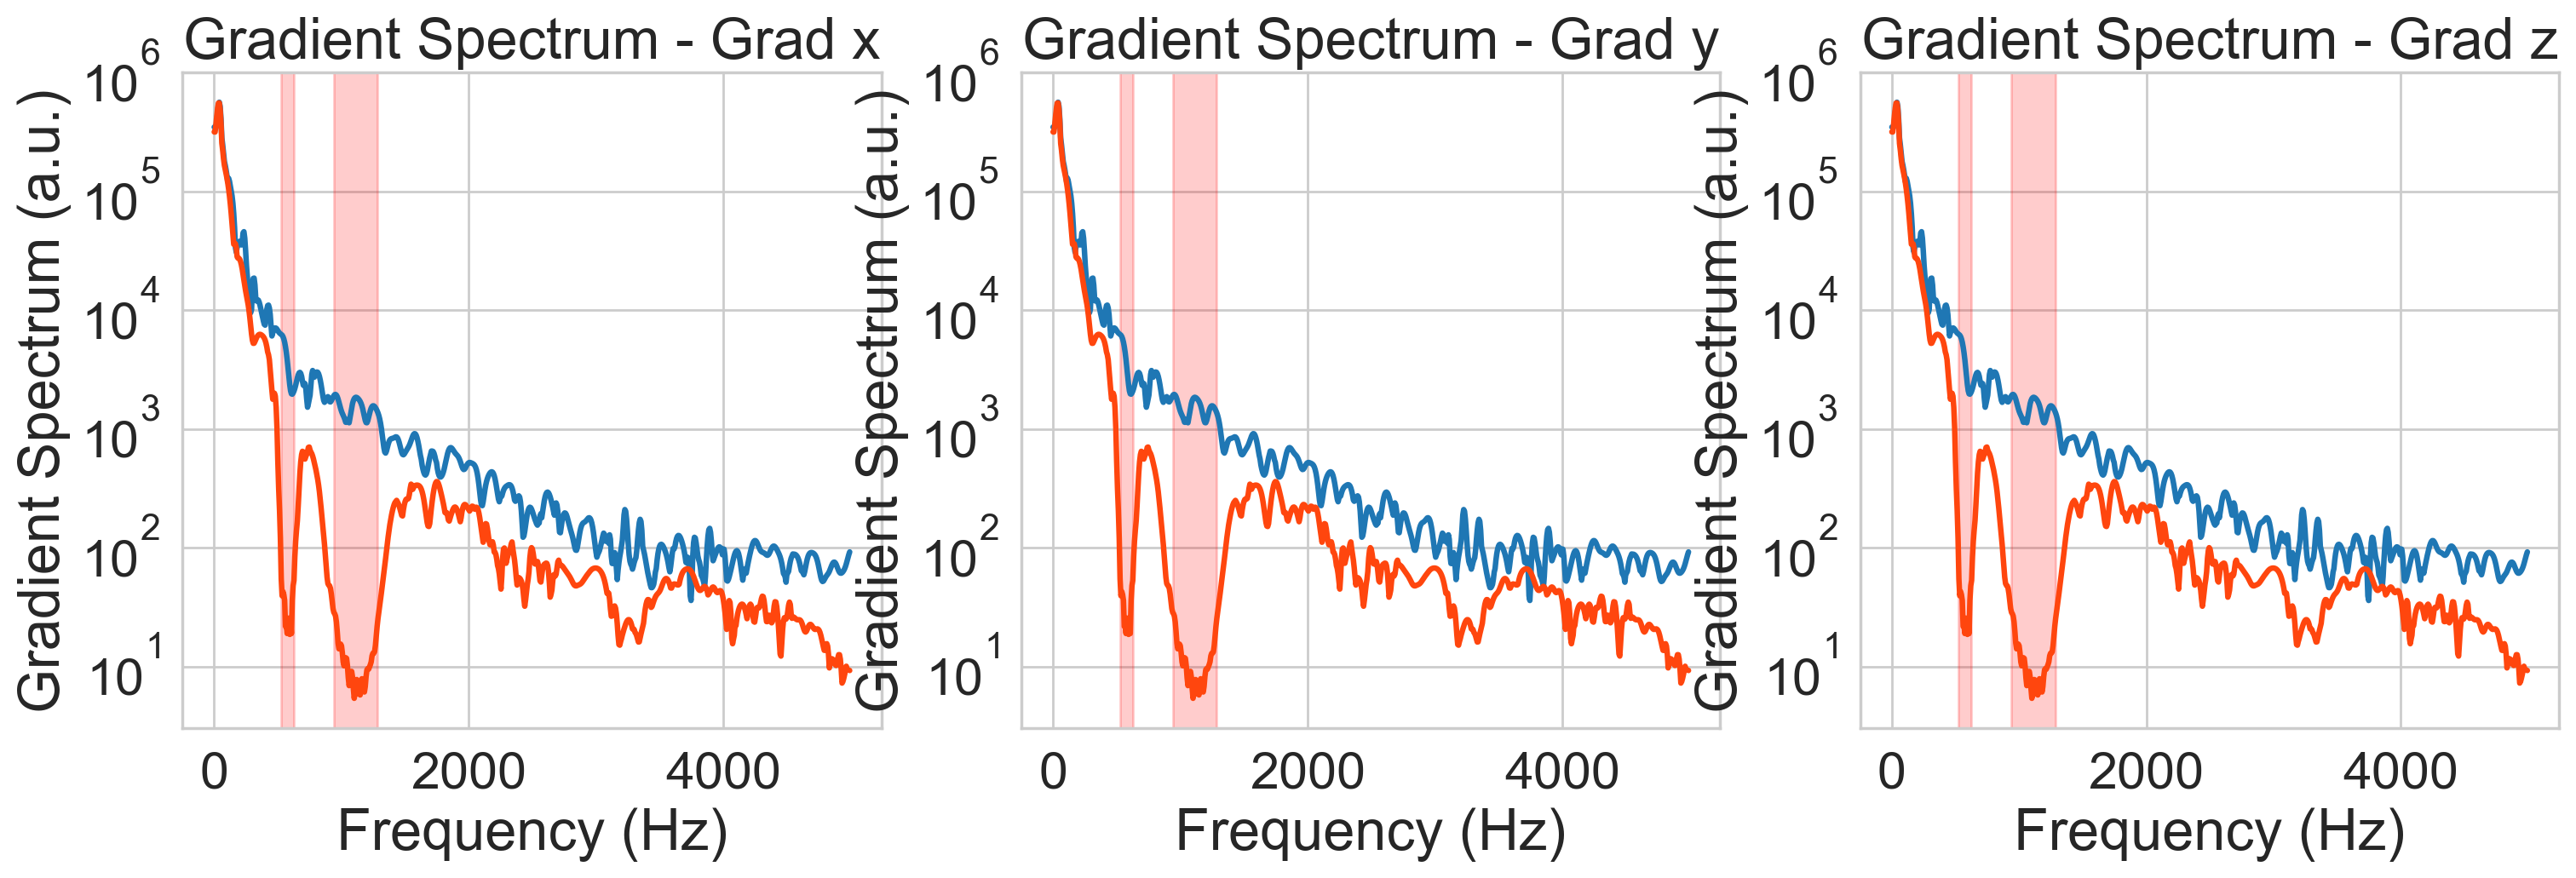

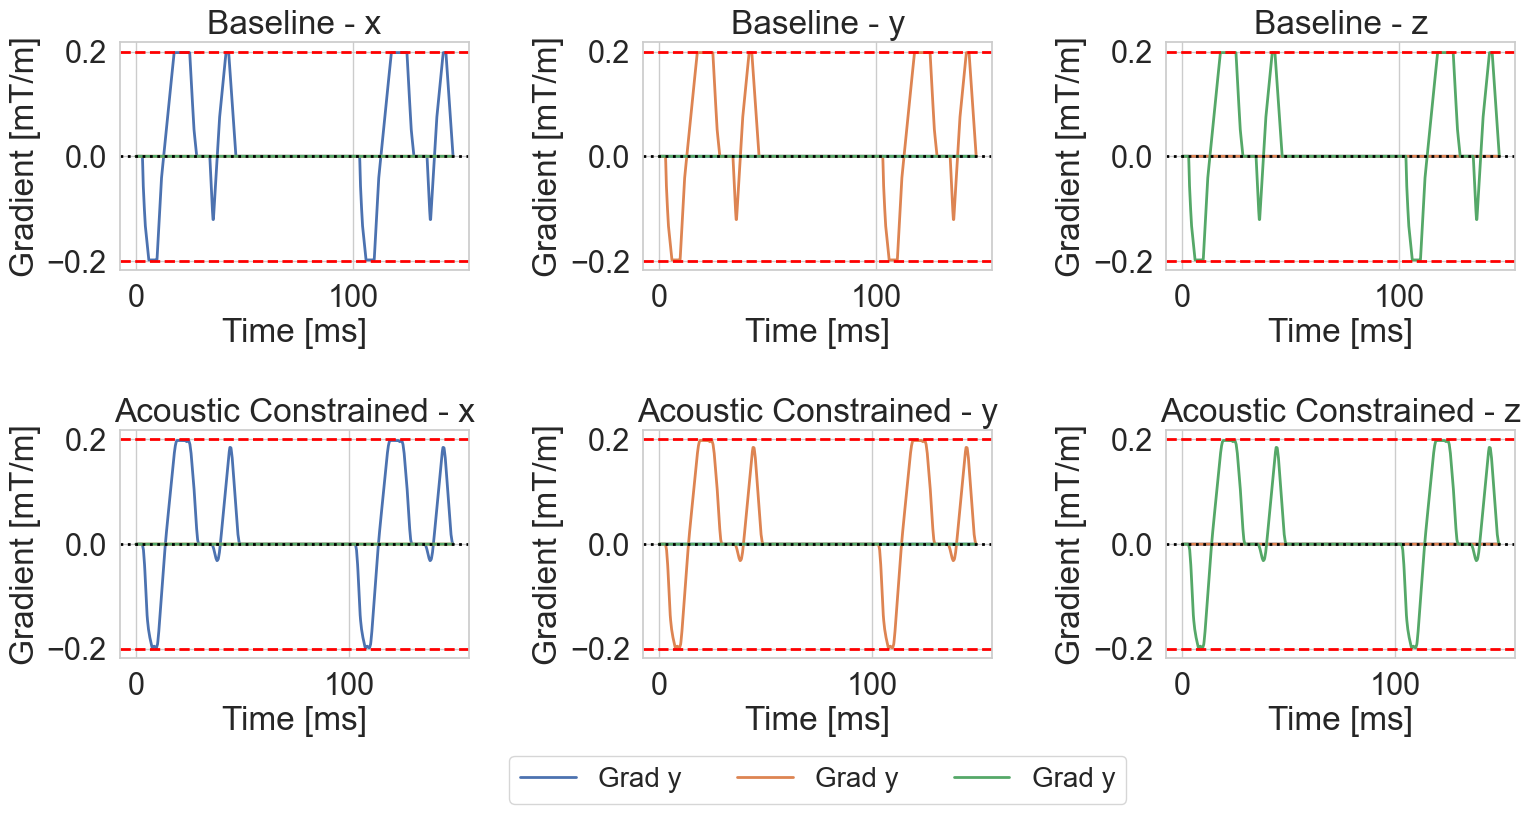

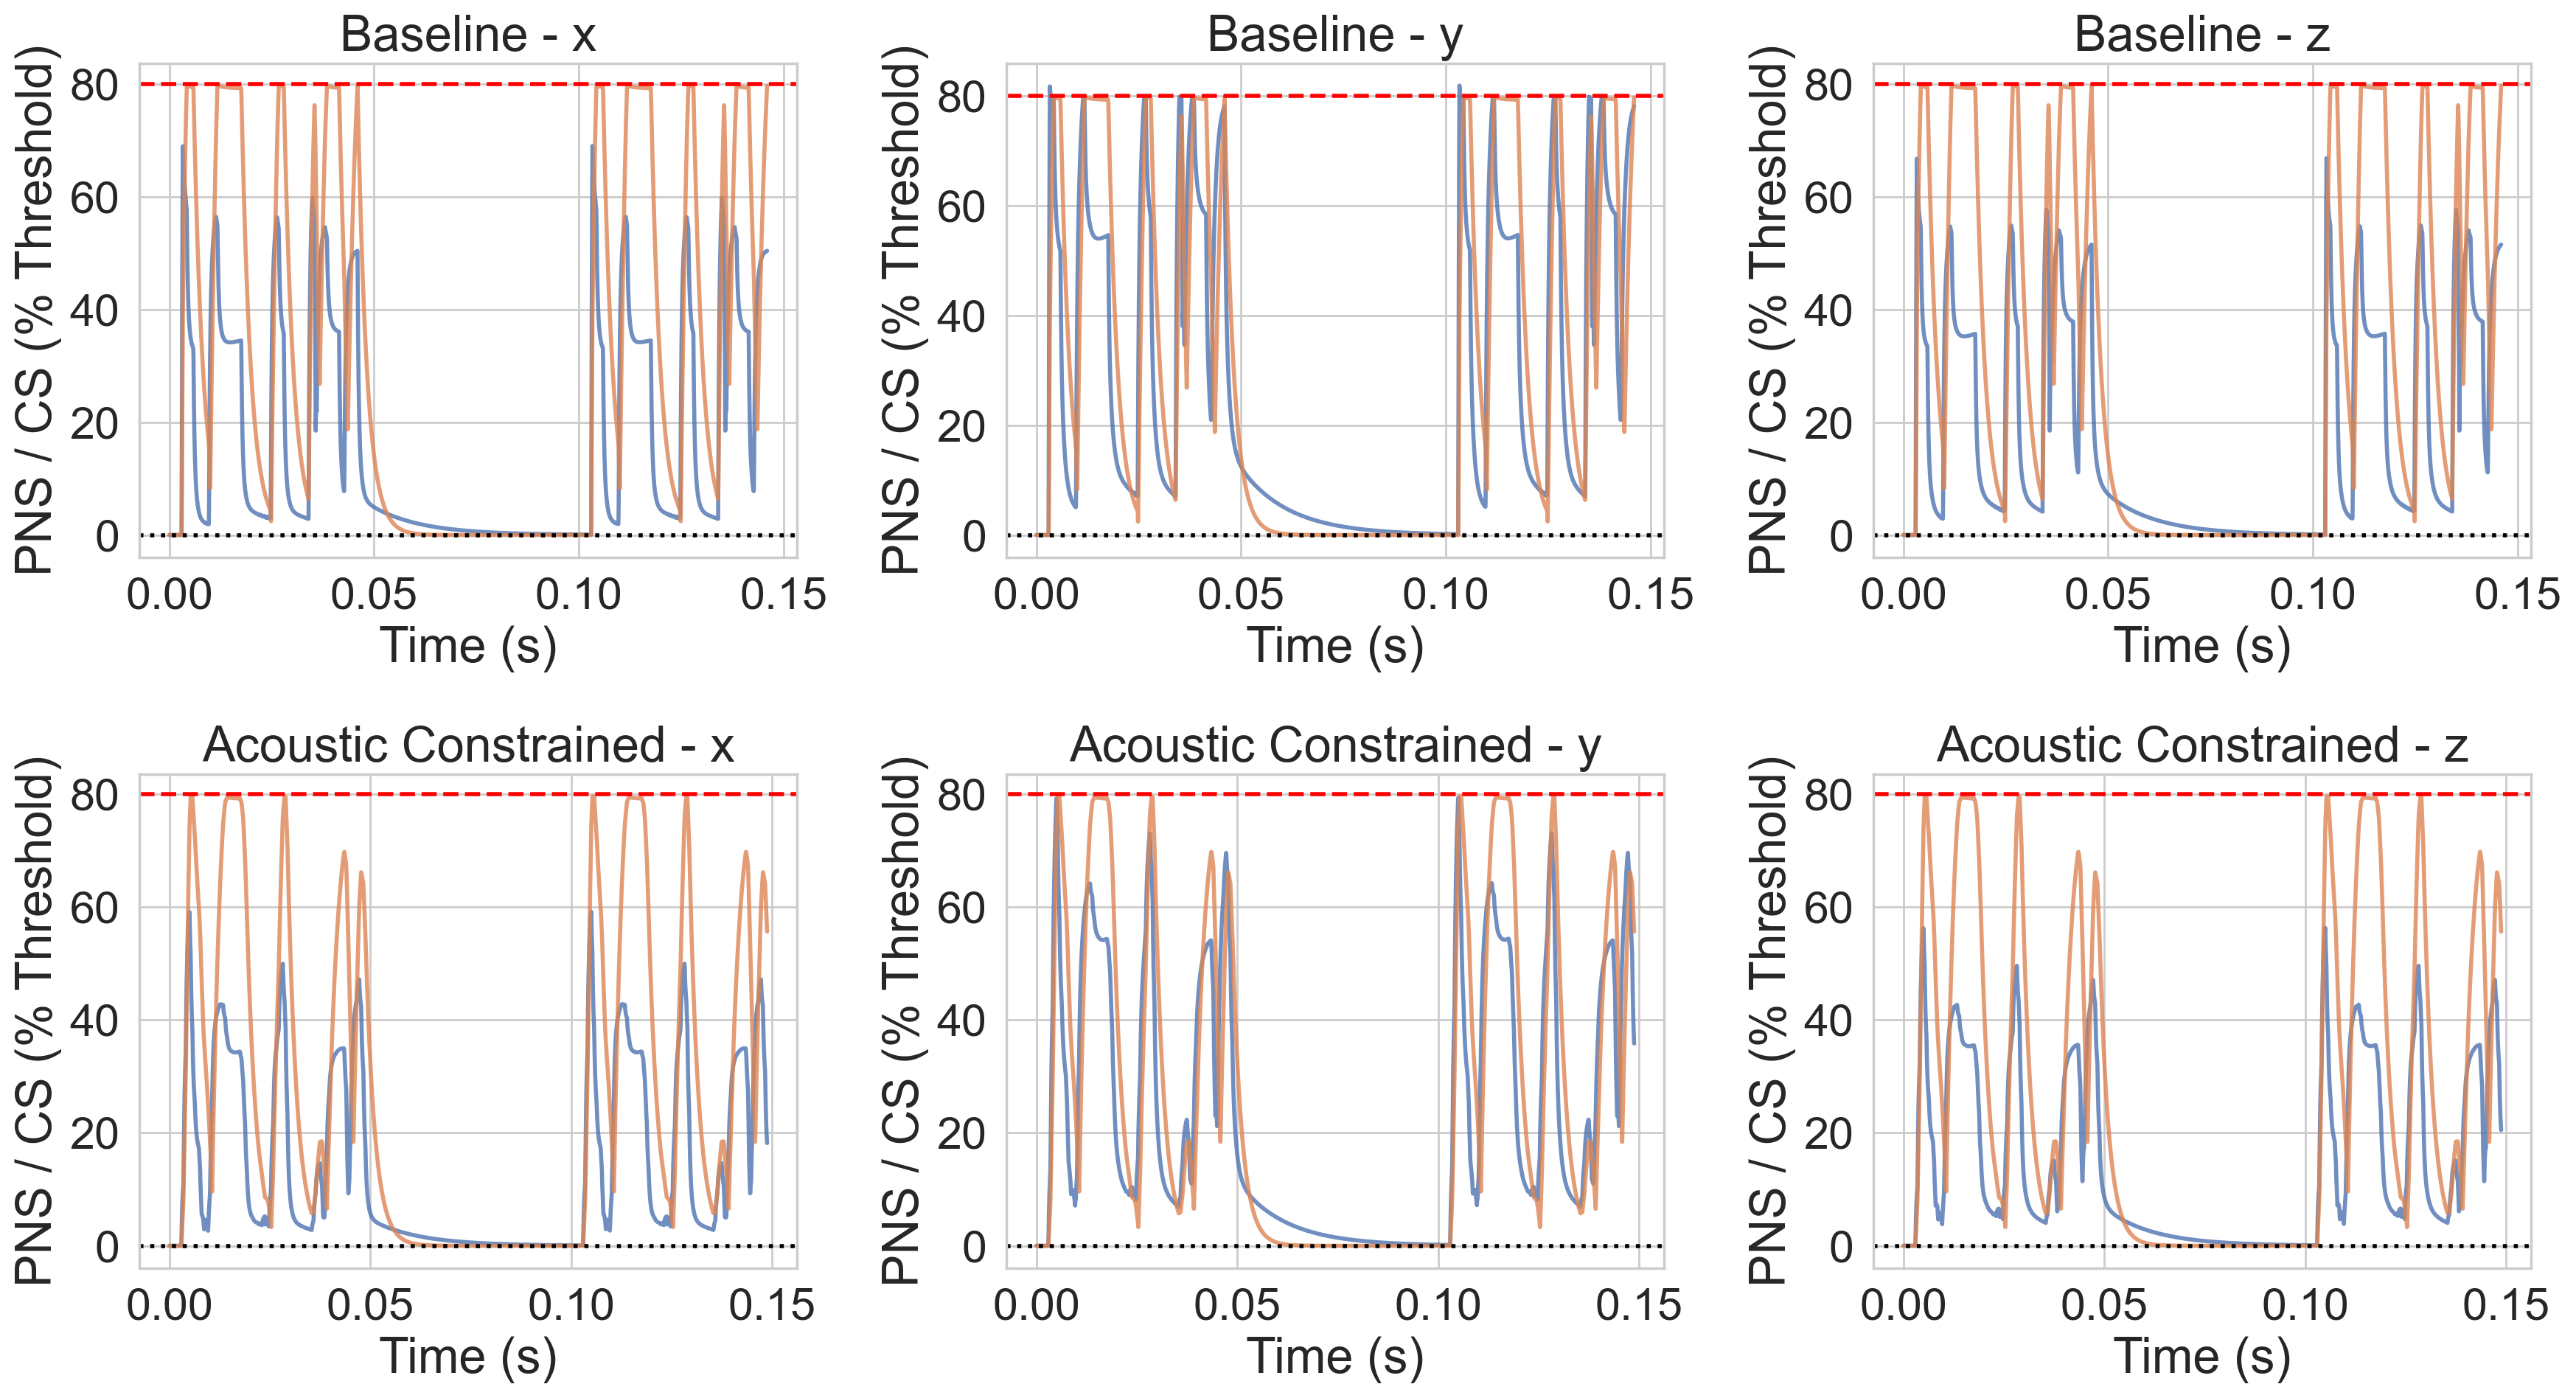

In [6]:
def get_grad_from_seq(s):
    # Get gradients as piecewise-polynomials
    gw_pp = s.get_gradients()
    ng = len(gw_pp)
    max_t = max(g.x[-1] for g in gw_pp if g is not None)

    # Determine sampling points
    nt = int(np.ceil(max_t / dt))
    t = (np.arange(nt) + 0.5) * dt

    # Sample gradients
    gw = np.zeros((ng, t.shape[0]))
    for i in range(ng):
        if gw_pp[i] is not None:
            gw[i] = gw_pp[i](t)
    gw/= sys.gamma  # Convert from rad/s/m to mT/m

    return t, gw

pns_norm = [[np.zeros(1) for _ in range(len(channel_list))] for _ in range(2)]
cs_norm = [[np.zeros(1) for _ in range(len(channel_list))] for _ in range(2)]
t_pns = [[np.zeros(1) for _ in range(len(channel_list))] for _ in range(2)]
t_cs = [[np.zeros(1) for _ in range(len(channel_list))] for _ in range(2)]
spectrum_list = [[np.zeros(1) for _ in range(len(channel_list))] for _ in range(2)]

for idx_s, s in enumerate(seq):
    for idx_ch, seq_ch in enumerate(s):
        ok, pns_norm_seq, _, t_pns_seq = seq_ch.calculate_pns(hw_pns, do_plots=False)
        ok, cs_norm_seq, _, t_cs_seq = seq_ch.calculate_pns(hw_cs, do_plots=False)
        pns_norm[idx_s][idx_ch] = pns_norm_seq
        cs_norm[idx_s][idx_ch] = cs_norm_seq
        t_pns[idx_s][idx_ch] = t_pns_seq
        t_cs[idx_s][idx_ch] = t_cs_seq
        _, spectrum_seq, freq_seq, timeaxis_seq = seq_ch.calculate_gradient_spectrum(max_frequency=5000, plot=False, acoustic_resonances=forbidden_frequency)
        spectrum_list[idx_s][idx_ch] = spectrum_seq

plt.figure(figsize=(18, 5), dpi=200)
for idx_ch, ch in enumerate(channel_list):
    plt.subplot(1,3,idx_ch+1)
    plt.plot(freq_seq, spectrum_list[0][idx_ch], label='Baseline', color=colors[0], linewidth=2.33)
    plt.plot(freq_seq, spectrum_list[1][idx_ch], label='Acoustic Constrained', color=colors[1], linewidth=2.33)
    for idx, (f, bw) in enumerate(zip(forbidden_frequencies, forbidden_bandwidths)):
        plt.axvspan(f - bw / 2, f + bw / 2, alpha=0.2, color="red", label="Forbidden Band" if idx == 0 else None)
    plt.yscale('log')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Gradient Spectrum (a.u.)')
    plt.title(f'Gradient Spectrum - Grad {ch}')

# Extract gradients from sequences
plt.figure(figsize=(18, 8))
for i in range(2):
    for j in range(3):
        t_seq, gw_seq = get_grad_from_seq(seq[i][j])
        print(f"Sequence {seq_type_list[i]}, Channel {channel_list[j]}: Extracted {len(t_seq)} gradient samples.")
        plt.subplot(2, 3, i*3 + j + 1)
        plt.plot(t_seq*1e3, gw_seq.T, label=f'Grad {channel_list[j]}', linewidth=2)
        plt.xlabel('Time [ms]')
        plt.ylabel('Gradient [mT/m]')
        plt.title(f'{seq_type_list[i]} - {channel_list[j]}')
        plt.axhline(sys.max_grad/sys.gamma, color='red', linestyle='--', linewidth=2)
        plt.axhline(-sys.max_grad/sys.gamma, color='red', linestyle='--', linewidth=2)
        plt.axhline(0, color='black', linestyle=':', linewidth=2)
plt.subplot(2, 3, 5)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.7), ncol=3, fontsize=20)
plt.subplots_adjust(hspace=0.7, wspace=0.5)

plt.figure(figsize=(18, 10), dpi=200)
for idx_type, seq_type in enumerate(seq_type_list):
    for idx_ch, ch in enumerate(channel_list):
        plt.subplot(2, 3, idx_type*3 + idx_ch + 1)
        plt.plot(t_pns[idx_type][idx_ch], pns_norm[idx_type][idx_ch]*100, label='PNS', alpha=0.8, lw=2)
        plt.plot(t_cs[idx_type][idx_ch], cs_norm[idx_type][idx_ch]*100, label='CS', alpha=0.8, lw=2)
        plt.axhline(search_params_base['pns_lim']*100, color='red', linestyle='--', linewidth=2, label='Threshold')
        plt.axhline(0, color='black', linestyle=':', linewidth=2)
        plt.xlabel('Time (s)')
        plt.ylabel('PNS / CS (% Threshold)')
        plt.title(f'{seq_type} - {ch}')
plt.tight_layout()